## 1. Setup and imports


In [1]:
# Notebook designed to run from a subdirectory
%matplotlib inline
import numpy as np
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt

import sys
sys.path.append("../")

import aif360.algorithms.preprocessing
from aif360.datasets import BinaryLabelDataset, StructuredDataset
from aif360.metrics import BinaryLabelDatasetMetric, ClassificationMetric
from aif360.algorithms.preprocessing.reweighing import Reweighing
from aif360.algorithms.inprocessing.adversarial_debiasing import AdversarialDebiasing
from aif360.metrics.utils import compute_boolean_conditioning_vector
from aif360.algorithms.postprocessing.calibrated_eq_odds_postprocessing import CalibratedEqOddsPostprocessing


# for definition of original models
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import GridSearchCV
# from sklearn.svm import SVC
# from xgboost import XGBClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


import tensorflow as tf
from IPython.display import Markdown, display
import warnings

2026-09-30 00:13:59.349452: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-09-30 00:13:59.426967: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-09-30 00:14:01.143742: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
/home/len_lin/Documents/ADNI/.venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):
pip install 'aif360[inFairness]'


## 2. Fairness metrics


In [2]:
# Wraps aif360 ClassificationMetric into a clean OrderedDict
from collections import OrderedDict
from aif360.metrics import ClassificationMetric

def compute_metrics(dataset_true, dataset_pred, 
                    unprivileged_groups, privileged_groups,
                    disp = True):
    """ Compute the key metrics """
    classified_metric_pred = ClassificationMetric(dataset_true,
                                                 dataset_pred, 
                                                 unprivileged_groups=unprivileged_groups,
                                                 privileged_groups=privileged_groups)
    metrics = OrderedDict()
    metrics["Balanced accuracy"] = 0.5*(classified_metric_pred.true_positive_rate()+
                                             classified_metric_pred.true_negative_rate())
    
    metrics["Average odds difference"] = classified_metric_pred.average_odds_difference()
    metrics["Disparate impact"] = classified_metric_pred.disparate_impact()
    metrics["Equal opportunity difference"] = classified_metric_pred.equal_opportunity_difference()
    metrics["Mean Difference"] = classified_metric_pred.mean_difference()
    metrics["Statistical parity difference"] = classified_metric_pred.statistical_parity_difference()
    metrics["Theil index"] = classified_metric_pred.theil_index()
    
    if disp:
        for k in metrics:
            print("%s = %.4f" % (k, metrics[k]))
    
    return metrics

## 3. Data preparation


In [3]:
# 757 subjects x 147 columns; Sex: 0=male, 1=female; DIAGNOSIS: 0=MCI, 1=AD
df = pd.read_csv('data_4mod_MCIvsAD.csv')
print(df.shape)
# df.head()

(757, 147)


In [4]:
# Check joint distribution of diagnosis and sex
# print(df.value_counts(subset=['DIAGNOSIS', 'Sex'], sort=False))

In [5]:
# print(df['Sex'].value_counts())
# df['Sex'].value_counts(normalize=True)
# print(df['DIAGNOSIS'].value_counts())

In [6]:
# Save PTIDs for later identification
df_PTID=df[['PTID']]
# print(df_PTID.shape)
# df_PTID.head()

In [7]:
# Drop metadata, diagnosis flags, and DXMPTR* proxy columns (18 total)
df = df.drop(['PTID','CDRSB', 'PTHAND', 'PTCOGBEG', 'DXDSEV','DXMDUE', 'DXMCI', 'DXAD', 'DXAPP', 'DXDDUE', 'PTADDX', 'ICV'], axis=1) 
df = df.drop(['DXMPTR1', 'DXMPTR2', 'DXMPTR3', 'DXMPTR4', 'DXMPTR5', 'DXMPTR6'], axis=1)
print(df.shape)
# df.head()

(757, 129)


In [8]:
# Sex=0 (male)=privileged, Sex=1 (female)=unprivileged; favorable label = AD (1)
# Binarize Training data
label_name = ['DIAGNOSIS']
protected_attribute_names = ['Sex']
    
dataset_Binary = BinaryLabelDataset(
    df=df,
    label_names=label_name,
    protected_attribute_names=protected_attribute_names,
    favorable_label=1,
    unfavorable_label=0)

unique_labels = dataset_Binary.labels.ravel() 

if len(np.unique(unique_labels)) != 2:
    raise ValueError("Dataset does not contain binary labels")
    
for attr in protected_attribute_names:
    unique_attrs = dataset_Binary.protected_attributes[:, dataset_Binary.protected_attribute_names.index(attr)]
    if len(np.unique(unique_attrs)) != 2:
        raise ValueError(f"Protected attribute '{attr}' is not binary")

In [9]:
# Get the dataset and split into train and test
# 66/34 split -> ~499 train / ~258 validation
dataset_orig_train, dataset_orig_valid = dataset_Binary.split([0.66])

privileged_groups = [{'Sex': 0}]
unprivileged_groups = [{'Sex': 1}]

In [10]:
metric_orig_train = BinaryLabelDatasetMetric(dataset_orig_train, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original training dataset"))
print("disparate impact = %f" % metric_orig_train.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_train.statistical_parity_difference())

#### Original training dataset

disparate impact = 0.823206
Statistical parity difference = -0.036119


In [11]:
metric_orig_valid = BinaryLabelDatasetMetric(dataset_orig_valid, 
                                             unprivileged_groups=unprivileged_groups,
                                             privileged_groups=privileged_groups)

display(Markdown("#### Original validation dataset"))
print("disparate impact = %f" % metric_orig_valid.disparate_impact())
print("Statistical parity difference = %f" % metric_orig_valid.statistical_parity_difference())

#### Original validation dataset

disparate impact = 1.167468
Statistical parity difference = 0.038007


In [12]:
X_train = dataset_orig_train.features
y_train = dataset_orig_train.labels.ravel()

# OS ratio in the training sample
# -------------------------------------
# uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
# display(Markdown("#### no of patients / controls in the Training dataset"))
# print(countsytrain)

In [13]:
# SMOTE resampling to balance MCI/AD (random_state=2 matches original analysis)
smote = SMOTE(random_state=2)
X_train_sampled, y_train_sampled = smote.fit_resample(X_train, y_train)

scale_orig = StandardScaler()
X_train = scale_orig.fit_transform(X_train_sampled)
y_train = y_train_sampled
X_valid = scale_orig.transform(dataset_orig_valid.features)


In [14]:
display(Markdown("#### Training Dataset shape after resampling"))
print(X_train.shape)

uniqueytrain, countsytrain = np.unique(y_train, return_counts=True)
display(Markdown("#### no of MCI / AD"))
print(countsytrain)

#### Training Dataset shape after resampling

(810, 128)


#### no of MCI / AD

[405 405]


## 4. Original model: training


SVC with poly kernel (C=0.1, gamma=0.1). Parameters were explored via GridSearchCV (C, kernel, gamma combinations); the chosen values are hardcoded for reproducibility.


In [15]:
# # # SVC with poly kernel; params pre-selected via GridSearch
# # model = SVC(C=0.1, gamma=0.1, kernel='poly', random_state=42, probability=True)


# model=LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
#                                    class_weight='balanced', random_state=42)
# model.fit(X_train, y_train)

In [16]:
# # Predict training labels into aif360 dataset format
# y_train_pred = model.predict(X_train)

# pos_ind = np.where(model.classes_ == dataset_orig_train.favorable_label)[0][0]
# dataset_orig_train_pred = dataset_orig_train.copy()
# dataset_orig_train_pred.labels = y_train_pred

In [17]:
# # Get probability scores on validation set for threshold tuning
# ## validation set
# dataset_orig_valid_pred = dataset_orig_valid.copy(deepcopy=True)
# X_test = scale_orig.transform(dataset_orig_valid_pred.features)
# y_test = dataset_orig_valid_pred.labels
# dataset_orig_valid_pred.scores = model.predict_proba(X_test)[:,pos_ind]

## 5. Original model: evaluation and threshold tuning


In [18]:
# # Scan 100 thresholds (0.01-0.99) to maximize balanced accuracy
# # Predictions from the original test set at the optimal classification threshold
# # Find the optimal classification threshold from the test set
# import numpy as np
# np.seterr(divide='ignore', invalid='ignore')

# num_thresh = 100
# ba_arr = np.zeros(num_thresh)
# class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
# for idx, class_thresh in enumerate(class_thresh_arr):
    
#     fav_inds = dataset_orig_valid_pred.scores > class_thresh
#     dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
#     dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
#     classified_metric_valid = ClassificationMetric(dataset_orig_valid,
#                                              dataset_orig_valid_pred, 
#                                              unprivileged_groups=unprivileged_groups,
#                                              privileged_groups=privileged_groups)
    
#     ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
#                        +classified_metric_valid.true_negative_rate())

# best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
# best_class_thresh = class_thresh_arr[best_ind]
# dataset_orig_valid_pred.unfavorable_label

# display(Markdown("#### Predictions from original testing data"))
# bal_acc_arr_orig = []
# avg_odds_diff_arr_orig = []
# disp_imp_arr_orig = []
# equal_opp_diff_arr_orig = [] #equal_opportunity_difference
# mean_diff_arr_orig = []
# stat_par_arr_orig = []
# theil_ind_arr_orig = []


# print("Classification threshold used = %.4f" % best_class_thresh)
# for thresh in tqdm(class_thresh_arr):
    
#     if thresh == best_class_thresh:
#         disp = True
#     else:
#         disp = False
    
#     fav_inds = dataset_orig_valid_pred.scores > thresh
#     dataset_orig_valid_pred.labels[fav_inds] = dataset_orig_valid_pred.favorable_label
#     dataset_orig_valid_pred.labels[~fav_inds] = dataset_orig_valid_pred.unfavorable_label
    
#     metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_orig_valid_pred, 
#                                       unprivileged_groups, privileged_groups,
#                                       disp = disp)

#     bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
#     avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
#     disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
#     equal_opp_diff_arr_orig.append(metric_valid_bef["Equal opportunity difference"])
#     mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])
#     stat_par_arr_orig.append(metric_valid_bef["Statistical parity difference"])
#     theil_ind_arr_orig.append(metric_valid_bef["Theil index"])

## 6. Debiasing with Disparate Impact Remover


In [19]:
# # DisparateImpactRemover pre-processing (repair_level=1 = full repair)
# DIR = aif360.algorithms.preprocessing.DisparateImpactRemover(
#        repair_level=1,  
#        sensitive_attribute='Sex')

# dataset_transf_train = DIR.fit_transform(dataset_orig_train)  

In [20]:
# metric_transf_train = BinaryLabelDatasetMetric(dataset_transf_train, 
#                                          unprivileged_groups=unprivileged_groups,
#                                          privileged_groups=privileged_groups)

# display(Markdown("#### Transformed training dataset "))
# print("mean difference = %f" % metric_transf_train.mean_difference())
# print("disparate impact = %f" % metric_transf_train.disparate_impact())
# print("Statistical parity difference = %f" % metric_transf_train.statistical_parity_difference())

## 7. Debiased model: training


In [21]:
# # SMOTE on debiased training data
# smote_transf = SMOTE(random_state=2)
# X_train_transf = dataset_transf_train.features
# y_train_transf = dataset_transf_train.labels.ravel()
# X_train_transf_sampled,y_train_transf_sampled = smote_transf.fit_resample(X_train_transf, y_train_transf)

# scale_transf = StandardScaler()
# X_train_transf = scale_transf.fit_transform(X_train_transf_sampled)
# y_train_transf = y_train_transf_sampled

In [22]:
# # Train SVC on the debiased (DisparateImpactRemover) features
# model_transf = LogisticRegression(C=1.0, penalty='l2', max_iter=1000,
#                                    class_weight='balanced', random_state=42)
# model_transf.fit(X_train_transf, y_train_transf)

# pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
# y_train_transf_pred = model_transf.predict(X_train_transf)

## 8. Debiased model: evaluation and threshold tuning


In [23]:
# dataset_transf_valid_pred = dataset_orig_valid.copy(deepcopy=True)
# X_test_transf = scale_transf.fit_transform(dataset_transf_valid_pred.features)
# y_test_transf = dataset_transf_valid_pred.labels
# dataset_transf_valid_pred.scores = model_transf.predict_proba(X_test_transf)[:, pos_ind]

In [24]:
# # Scan thresholds for debiased model predictions
# # Predictions from the transformed test set at the optimal classification threshold
# num_thresh = 100
# ba_arr = np.zeros(num_thresh)
# class_thresh_arr_transf = np.linspace(0.01, 0.99, num_thresh)
# for idx, class_thresh in enumerate(class_thresh_arr_transf):
    
#     fav_inds = dataset_transf_valid_pred.scores > class_thresh
#     dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#     dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
#     classified_metric_valid_transf = ClassificationMetric(dataset_orig_valid,
#                                              dataset_transf_valid_pred, 
#                                              unprivileged_groups=unprivileged_groups,
#                                              privileged_groups=privileged_groups)
    
#     ba_arr[idx] = 0.5*(classified_metric_valid_transf.true_positive_rate()\
#                        +classified_metric_valid_transf.true_negative_rate())

# best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
# best_class_thresh = class_thresh_arr_transf[best_ind]

# display(Markdown("#### Predictions from transformed testing data"))
# bal_acc_arr_transf = []
# avg_odds_diff_arr_transf = []
# disp_imp_arr_transf = []
# equal_opp_diff_arr_transf = [] #equal_opportunity_difference
# mean_diff_arr_transf = []
# stat_par_arr_transf = []
# theil_ind_arr_transf = []

# print("Classification threshold used = %.4f" % best_class_thresh)
# for thresh in tqdm(class_thresh_arr_transf):
    
#     if thresh == best_class_thresh:
#         disp = True
#     else:
#         disp = False
    
#     fav_inds = dataset_transf_valid_pred.scores > thresh
#     dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#     dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
#     metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
#                                       unprivileged_groups, privileged_groups,
#                                       disp = disp)

#     bal_acc_arr_transf.append(metric_valid_aft["Balanced accuracy"])
#     avg_odds_diff_arr_transf.append(metric_valid_aft["Average odds difference"])
#     disp_imp_arr_transf.append(metric_valid_aft["Disparate impact"])
#     equal_opp_diff_arr_transf.append(metric_valid_aft["Equal opportunity difference"])
#     mean_diff_arr_transf.append(metric_valid_aft["Mean Difference"])
#     stat_par_arr_transf.append(metric_valid_aft["Statistical parity difference"])
#     theil_ind_arr_transf.append(metric_valid_aft["Theil index"])

In [25]:
# y_valid = dataset_orig_valid.labels
# # y_pred = dataset_orig_valid_pred.labels

# from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# %matplotlib inline
# cm_orig = confusion_matrix(y_valid, y_test)

# disp = ConfusionMatrixDisplay(confusion_matrix=cm_orig)
# disp.plot()
# plt.show()

In [26]:
# cm_transf = confusion_matrix(y_valid, y_test_transf)

# disp = ConfusionMatrixDisplay(confusion_matrix=cm_transf)
# disp.plot()
# plt.show()

## 9. Identification of 'corrected' patients


In [27]:
# # Extract PTIDs of validation set for result tracking
# # # identify PTIDs of test cases
# test_PTIDs = df_PTID[499:757] 
# # print(test_PTIDs[:5])
# # print (dataset_orig_valid.instance_names[:5])
# test_PTIDs.reset_index(inplace=True)
# test_PTIDs['index']
# test_PTIDs = test_PTIDs.drop(['index'], axis=1) 
# test_PTIDs

In [28]:
# # Build comparison dataframe: true vs original vs debiased predictions
# protected_attributes = dataset_transf_valid_pred.protected_attributes
# protected_attributes.ravel()

# df_ind = pd.DataFrame({
#     "y_true": dataset_orig_valid.labels.ravel(),
#     "pred_orig": dataset_orig_valid_pred.labels.ravel(),         
#     "pred_transf": dataset_transf_valid_pred.labels.ravel(),                   
#     "protected_attr": protected_attributes.ravel()
# })
# df_ind["Sex"] = df_ind["protected_attr"].map({0: "Male", 1: "Female"})
# print(df_ind.shape)
# df_ind.head()

In [29]:
# df_ind = pd.merge(test_PTIDs, df_ind, left_index=True, right_index=True)
# print(df_ind.shape)
# df_ind.tail()

In [30]:
# # Identify cases misclassified by original but corrected by debiasing
# improved_cases = df_ind[(df_ind['pred_orig'] != df_ind['y_true']) & (df_ind['pred_transf'] == df_ind['y_true'])]
# # Print the result
# print("Cases where the prediction was wrong before but correct after debiasing:")
# print(len(improved_cases))
# print(improved_cases[['PTID', 'y_true', 'pred_orig', 'pred_transf', 'Sex']])

## 10. Model interpretation with LIME


In [31]:
# # LIME tabular explainer for interpretability
# import lime
# import lime.lime_tabular
# from IPython.core.display import display, HTML
# import warnings

In [32]:
# # Note: df.columns[1:150] is fragile — assumes consistent column ordering
# X_train_XAI = pd.DataFrame(X_train)  
# X_train_XAI.columns=df.columns[1:150]

# X_test_XAI = pd.DataFrame(X_test) 
# X_test_XAI.columns=df.columns[1:150]


# # # Create a LIME explainer
# class_names = [0, 1]
# feature_names = list(X_train_XAI.columns)
# explainer = lime.lime_tabular.LimeTabularExplainer(X_train_XAI.values, feature_names=feature_names, 
#                                                         class_names=class_names, discretize_continuous=True)

In [33]:
# improved_cases.index
# improved_cases.Sex

In [34]:
# # List of test instance indices
# instance_indices = improved_cases.index #[4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]


# # Store results
# all_lime_values = []

# for idx in instance_indices:
#     # Explain instance with LIME
#     exp = explainer.explain_instance(X_test[idx], model.predict_proba, num_features=len(feature_names))
    
#     # Convert to dictionary
#     lime_dict = dict(exp.as_list())
    
#     # Ensure all features are present
#     for f in feature_names:
#         if f not in lime_dict:
#             lime_dict[f] = 0.0  # fill missing features with 0 contribution
    
#     # Add instance index
#     lime_dict['instance_index'] = idx
    
#     # Append to list
#     all_lime_values.append(lime_dict)

# # Convert to DataFrame
# lime_df = pd.DataFrame(all_lime_values)

# # # Ensure instance_index is first column
# # cols = ['instance_index'] + feature_names
# # lime_df = lime_df[cols]

# # lime_df = pd.DataFrame(all_lime_values)
# # print(lime_df.shape)
# # lime_df.head()

In [35]:
# Sex = {'Male': 0,'Female': 1}
# improved_cases.Sex = [Sex[item] for item in improved_cases.Sex]
# improved_cases.Sex

In [36]:
# df_lime_orig = lime_df.drop(['instance_index'], axis = 1)
# df_lime_orig = df_lime_orig.dropna(axis=1)
# df_lime_orig['gender'] = improved_cases['Sex'].values #[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]  
# print(df_lime_orig.shape)
# df_lime_orig.head()

In [37]:
# df_lime_orig_males = df_lime_orig[df_lime_orig['gender'] == 0] 
# df_lime_orig_females = df_lime_orig[df_lime_orig['gender'] == 1] 

In [38]:
# # Prepare transformed data for LIME comparison
# X_train_transf = pd.DataFrame(X_train_transf) 
# X_train_transf.columns=df.columns[1:150]

# # X_test_transf = pd.DataFrame(X_test_transf) 
# # X_test_transf.columns=df.columns[1:150]

# # Create a LIME explainer
# class_names = [0, 1]
# feature_names_transf = list(X_train_transf.columns)
# explainer_lime_transf = lime.lime_tabular.LimeTabularExplainer(X_train_transf.values, feature_names=feature_names_transf, 
#                                                         class_names=class_names, discretize_continuous=True)

In [39]:
# # List of test instance indices
# instance_indices = improved_cases.index #[4, 33, 46, 48, 112, 152, 153, 178, 191, 203, 220, 233, 237]

# # Store results
# all_lime_values_transf= []

# for idx in instance_indices:
#     # Explain instance with LIME
#     exp_transf = explainer_lime_transf.explain_instance(X_test_transf[idx], model_transf.predict_proba, num_features=len(feature_names))
    
#     # Convert to dictionary
#     lime_dict_transf = dict(exp_transf.as_list())
    
#     # Ensure all features are present
#     for f in feature_names:
#         if f not in lime_dict_transf:
#             lime_dict_transf[f] = 0.0  # fill missing features with 0 contribution
    
#     # Add instance index
#     lime_dict_transf['instance_index'] = idx
    
#     # Append to list
#     all_lime_values_transf.append(lime_dict_transf)

# # Convert to DataFrame
# lime_df_transf = pd.DataFrame(all_lime_values_transf)

# # # Ensure instance_index is first column
# # cols = ['instance_index'] + feature_names
# # lime_df_transf = lime_df_transf[cols]

# # Display
# # print(lime_df_transf.shape)
# # lime_df_transf.head()

In [40]:
# df_lime_transf = lime_df_transf.drop(['instance_index'], axis = 1)
# df_lime_transf = df_lime_transf.dropna(axis=1)
# df_lime_transf['gender'] = improved_cases['Sex'].values #[1, 1, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0]
# df_lime_transf.shape

In [41]:
# df_lime_transf_males = df_lime_transf[df_lime_transf['gender'] == 0] 
# df_lime_transf_females = df_lime_transf[df_lime_transf['gender'] == 1] 

In [42]:
### ========================================================
### test for statistical significance of feature importance 
### using sex-specific one-sample t-tests on lime values  
### before and after de-biasing
### p-values are corrected for multiple comparisons 
### ========================================================

# from scipy import stats

# # Hypothesized population mean (mu = 0)
# population_mean = 0

# # Create an empty dictionary to store results
# results_orig_males = {}

# # Number of tests (columns in the DataFrame)
# num_tests = len(df_lime_orig_males.columns)

# # Bonferroni-adjusted significance level (alpha = 0.05)
# alpha_bonferroni_orig_males = 0.05 / num_tests

# # Perform one-sample t-test across columns
# for column in df_lime_orig_males.columns:
#     sample_data_orig_males = df_lime_orig_males[column]
#     # Descriptive statistics
#     mean_orig_males = sample_data_orig_males.mean()
#     sd_orig_males = sample_data_orig_males.std(ddof=1)

#     # One-sample t-test
#     t_statistic_orig_males, p_value_orig_males = stats.ttest_1samp(sample_data_orig_males, population_mean)
    
#     # Check if the mean is significantly greater than 0 (one-tailed test)
#     if t_statistic_orig_males > 0:
#         p_value_orig_males /= 2  # one-tailed test for 'greater than 0'
    
#     results_orig_males[column] = {
#         'Mean': mean_orig_males,
#         'SD': sd_orig_males,
#         'T-statistic': t_statistic_orig_males,
#         'P-value': p_value_orig_males,
#         'Reject Null Hypothesis': p_value_orig_males < alpha_bonferroni_orig_males
#     }

# # Filter out only significant columns (those where the null hypothesis is rejected)
# significant_results_orig_males = {column: result for column, result in results_orig_males.items() if result['P-value'] < alpha_bonferroni_orig_males}

# # ---- Bar Plot for Significant Features (T-statistics and P-values) ----

# if significant_results_orig_males:
#     # Set up the figure for the subplot
#     plt.figure(figsize=(10, 6))

#     # T-statistics plot (Horizontal Bar Plot)
#     plt.barh(list(significant_results_orig_males.keys()), [result['T-statistic'] for result in significant_results_orig_males.values()], color='skyblue')
#     plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
#     plt.title('Significant T-statistics of missed male AD patient before de-biasing')
#     plt.xlabel('T-statistic')

#     # Adjust layout for better visualization
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

#     # Print significant results
#     print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_males:.5f}):\n")
#     for column, result in significant_results_orig_males.items():
#         print(f"Results for {column}:")
#         print(f"Mean: {result['Mean']:.3f}")
#         print(f"SD: {result['Mean']:.3f}")
#         print(f"T-statistic: {result['T-statistic']:.3f}")
#         print(f"P-value: {result['P-value']:.3f}")
# else:
#     print("No significant results after Bonferroni correction.")

In [43]:
# # # One-sample t-test of LIME feature contributions vs mean=0, by sex
# # from scipy import stats

# # # Hypothesized population mean (mu = 0)
# # population_mean = 0

# # Create an empty dictionary to store results
# results_orig_females = {}

# # Number of tests (columns in the DataFrame)
# num_tests = len(df_lime_orig_females.columns)

# # Bonferroni-adjusted significance level (alpha = 0.05)
# alpha_bonferroni_orig_females = 0.05 / num_tests

# # Perform one-sample t-test across columns
# for column in df_lime_orig_females.columns:
#     sample_data_orig_females = df_lime_orig_females[column]
    
#     # Descriptive statistics
#     mean_orig_females = sample_data_orig_females.mean()
#     sd_orig_females = sample_data_orig_females.std(ddof=1)

#     # One-sample t-test
#     t_statistic_orig_females, p_value_orig_females = stats.ttest_1samp(sample_data_orig_females, population_mean)
    
#     # Check if the mean is significantly greater than 0 (one-tailed test)
#     if t_statistic_orig_females > 0:
#         p_value_orig_females /= 2  # one-tailed test for 'greater than 0'
    
#     # Store results
#     results_orig_females[column] = {
#         'Mean': mean_orig_females,
#         'SD': sd_orig_females,        
#         'T-statistic': t_statistic_orig_females,
#         'P-value': p_value_orig_females,
#         'Reject Null Hypothesis': p_value_orig_females < alpha_bonferroni_orig_females
#     }

# # Filter out only significant columns (those where the null hypothesis is rejected)
# significant_results_orig_females = {column: result for column, result in results_orig_females.items() if result['P-value'] < alpha_bonferroni_orig_females}

# # ---- Bar Plot for Significant Features (T-statistics and P-values) ----

# if significant_results_orig_females:
#     # Set up the figure for the subplot
#     plt.figure(figsize=(10, 6))

#     # T-statistics plot (Horizontal Bar Plot)
#     plt.barh(list(significant_results_orig_females.keys()), [result['T-statistic'] for result in significant_results_orig_females.values()], color='#D32F2F')
#     plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
#     plt.title('Significant T-statistics of missed female AD patient before de-biasing')
#     plt.xlabel('T-statistic')

#     # Adjust layout for better visualization
#     plt.tight_layout()

#     # Show the plot
#     plt.show();

#     # Print significant results
#     print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_orig_females:.5f}):\n")
#     for column, result in significant_results_orig_females.items():
#         print(f"Results for {column}:")
#         print(f"Mean: {result['Mean']:.3f}")
#         print(f"SD: {result['SD']:.3f}")
#         print(f"T-statistic: {result['T-statistic']:.3f}")
#         print(f"P-value: {result['P-value']:.3f}")
# else:
#     print("No significant results after Bonferroni correction.")

In [44]:
# # One-sample t-test of LIME feature contributions vs mean=0, by sex
# # Hypothesized population mean (mu = 0)
# # population_mean = 0

# # Create an empty dictionary to store results
# results_transf_males = {}

# # Number of tests (columns in the DataFrame)
# num_tests = len(df_lime_transf_males.columns)

# # Bonferroni-adjusted significance level (alpha = 0.05)
# alpha_bonferroni_transf_males = 0.05 / num_tests

# # Perform one-sample t-test across columns
# for column in df_lime_transf_males.columns:
#     sample_data_transf_males = df_lime_transf_males[column]

#     # Descriptive statistics
#     mean_transf_males = sample_data_transf_males.mean()
#     sd_transf_males = sample_data_transf_males.std(ddof=1)

#     # One-sample t-test    
#     t_statistic_transf_males, p_value_transf_males = stats.ttest_1samp(sample_data_transf_males, population_mean)
    
#     # Check if the mean is significantly greater than 0 (one-tailed test)
#     if t_statistic_transf_males > 0:
#         p_value_transf_males /= 2  # one-tailed test for 'greater than 0'
    
#     # Store results
#     results_transf_males[column] = {
#         'Mean': mean_transf_males,
#         'SD': sd_transf_males,    
#         'T-statistic': t_statistic_transf_males,
#         'P-value': p_value_transf_males,
#         'Reject Null Hypothesis': p_value_transf_males < alpha_bonferroni_transf_males
#     }

# # Filter out only significant columns (those where the null hypothesis is rejected)
# significant_results_transf_males = {column: result for column, result in results_transf_males.items() if result['P-value'] < alpha_bonferroni_transf_males}

# # ---- Bar Plot for Significant Features (T-statistics and P-values) ----

# if significant_results_transf_males:
#     # Set up the figure for the subplot
#     plt.figure(figsize=(10, 6))

#     # T-statistics plot (Horizontal Bar Plot)
#     plt.barh(list(significant_results_transf_males.keys()), [result['T-statistic'] for result in significant_results_transf_males.values()], color='skyblue')
#     plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
#     plt.title('Significant T-statistics of corrected male AD patient')
#     plt.xlabel('T-statistic')

#     # Adjust layout for better visualization
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

#     # Print significant results
#     print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_males:.5f}):\n")
#     for column, result in significant_results_transf_males.items():
#         print(f"Results for {column}:")
#         print(f"Mean: {result['Mean']:.3f}")
#         print(f"SD: {result['SD']:.3f}")
#         print(f"T-statistic: {result['T-statistic']:.3f}")
#         print(f"P-value: {result['P-value']:.3f}")
# else:
#     print("No significant results after Bonferroni correction.")

In [45]:
# # One-sample t-test of LIME feature contributions vs mean=0, by sex
# # # Hypothesized population mean (mu = 0)
# # population_mean = 0

# # Create an empty dictionary to store results
# results_transf_females = {}

# # Number of tests (columns in the DataFrame)
# num_tests = len(df_lime_transf_females.columns)

# # Bonferroni-adjusted significance level (alpha = 0.05)
# alpha_bonferroni_transf_females = 0.05 / num_tests

# # Perform one-sample t-test across columns
# for column in df_lime_transf_females.columns:
#     sample_data_transf_females = df_lime_transf_females[column]

#     # Descriptive statistics
#     mean_transf_females = sample_data_transf_females.mean()
#     sd_transf_females = sample_data_transf_females.std(ddof=1)

#     # One-sample t-test    
#     t_statistic_transf_females, p_value_transf_females = stats.ttest_1samp(sample_data_transf_females, population_mean)
    
#     # Check if the mean is significantly greater than 0 (one-tailed test)
#     if t_statistic_transf_females > 0:
#         p_value_transf_females /= 2  # one-tailed test for 'greater than 0'
    
#     # Store results
#     results_transf_females[column] = {
#         'Mean': mean_transf_females,
#         'SD': sd_transf_females,    
#         'T-statistic': t_statistic_transf_females,
#         'P-value': p_value_transf_females,
#         'Reject Null Hypothesis': p_value_transf_females < alpha_bonferroni_transf_females
#     }

# # Filter out only significant columns (those where the null hypothesis is rejected)
# significant_results_transf_females = {column: result for column, result in results_transf_females.items() if result['P-value'] < alpha_bonferroni_transf_females}

# # ---- Bar Plot for Significant Features (T-statistics and P-values) ----

# if significant_results_transf_females:
#     # Set up the figure for the subplot
#     plt.figure(figsize=(10, 6))

#     # T-statistics plot (Horizontal Bar Plot)
#     plt.barh(list(significant_results_transf_females.keys()), [result['T-statistic'] for result in significant_results_transf_females.values()], color='#D32F2F')
#     plt.axvline(0, color='black', linewidth=1)  # Line at T = 0 for comparison
#     plt.title('Significant T-statistics of corrected female AD patient')
#     plt.xlabel('T-statistic')

#     # Adjust layout for better visualization
#     plt.tight_layout()

#     # Show the plot
#     plt.show()

#     # Print significant results
#     print(f"Significant Results (after Bonferroni correction, p-value < {alpha_bonferroni_transf_females:.5f}):\n")
#     for column, result in significant_results_transf_females.items():
#         print(f"Results for {column}:")
#         print(f"Mean: {result['Mean']:.3f}")
#         print(f"SD: {result['SD']:.3f}")
#         print(f"T-statistic: {result['T-statistic']:.3f}")
#         print(f"P-value: {result['P-value']:.3f}")
# else:
#     print("No significant results after Bonferroni correction.")

In [46]:
# print(len(df_lime_orig_females.columns))
# print(len(df_lime_orig_males.columns))
# print(len(df_lime_transf_females.columns))
# print(len(df_lime_transf_males.columns))

---
## Appendix: additional mitigation algorithms


These methods were explored but not included in the main analysis. Code is preserved for reference.


### Adversarial Debiasing (in-processing, TF-based)


In [47]:
warnings.filterwarnings("ignore")
tf.compat.v1.disable_eager_execution()  # Ensure TF2 compatibility
sess = tf.compat.v1.Session()
plain_model = aif360.algorithms.inprocessing.AdversarialDebiasing(
   privileged_groups=privileged_groups,
   unprivileged_groups=unprivileged_groups,
   scope_name='original_model',
   debias=False,
   sess=sess,
   num_epochs=50,
   batch_size=128,
   classifier_num_hidden_units=128
)


plain_model.fit(dataset_orig_train)
dataset_nodebiasing_train = plain_model.predict(dataset_orig_train) 
dataset_nodebiasing_valid = plain_model.predict(dataset_orig_valid) 

Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.


2026-09-30 00:14:02.885283: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected
Instructions for updating:
Please use `rate` instead of `keep_prob`. Rate should be set to `rate = 1 - keep_prob`.
I0000 00:00:1790720043.146210   99929 mlir_graph_optimization_pass.cc:437] MLIR V1 optimization pass is not enabled


epoch 0; iter: 0; batch classifier loss: 3.559048
epoch 1; iter: 0; batch classifier loss: 1.554312
epoch 2; iter: 0; batch classifier loss: 1.024529
epoch 3; iter: 0; batch classifier loss: 1.099328
epoch 4; iter: 0; batch classifier loss: 0.894000
epoch 5; iter: 0; batch classifier loss: 0.907814
epoch 6; iter: 0; batch classifier loss: 1.029899
epoch 7; iter: 0; batch classifier loss: 0.904529
epoch 8; iter: 0; batch classifier loss: 0.866961
epoch 9; iter: 0; batch classifier loss: 0.874080
epoch 10; iter: 0; batch classifier loss: 0.801141
epoch 11; iter: 0; batch classifier loss: 0.549568
epoch 12; iter: 0; batch classifier loss: 0.395822
epoch 13; iter: 0; batch classifier loss: 0.492715
epoch 14; iter: 0; batch classifier loss: 0.770267
epoch 15; iter: 0; batch classifier loss: 0.556559
epoch 16; iter: 0; batch classifier loss: 0.558672
epoch 17; iter: 0; batch classifier loss: 0.680955
epoch 18; iter: 0; batch classifier loss: 0.499288
epoch 19; iter: 0; batch classifier loss:

In [48]:
num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr):
 
   fav_inds = dataset_nodebiasing_valid.scores > class_thresh
   dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
   dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
   
   classified_metric_valid = ClassificationMetric(dataset_orig_valid,
                                            dataset_nodebiasing_valid, 
                                            unprivileged_groups=unprivileged_groups,
                                            privileged_groups=privileged_groups)
    
   ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
                      +classified_metric_valid.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh = class_thresh_arr[best_ind]

display(Markdown("#### Predictions from testing data before Adversarial Debiasing"))
bal_acc_arr_orig = []
disp_imp_arr_orig = []
# avg_odds_diff_arr_orig = []
mean_diff_arr_orig = []

print("Classification threshold used = %.4f" % best_class_thresh)
for thresh in tqdm(class_thresh_arr):
   
   if thresh == best_class_thresh:
       disp = True
   else:
       disp = False
   
   fav_inds = dataset_nodebiasing_valid.scores > thresh
   dataset_nodebiasing_valid.labels[fav_inds] = dataset_nodebiasing_valid.favorable_label
   dataset_nodebiasing_valid.labels[~fav_inds] = dataset_nodebiasing_valid.unfavorable_label
    
   metric_valid_bef = compute_metrics(dataset_orig_valid, dataset_nodebiasing_valid, 
                                     unprivileged_groups, privileged_groups,
                                     disp = disp)

   bal_acc_arr_orig.append(metric_valid_bef["Balanced accuracy"])
   # avg_odds_diff_arr_orig.append(metric_valid_bef["Average odds difference"])
   disp_imp_arr_orig.append(metric_valid_bef["Disparate impact"])
   mean_diff_arr_orig.append(metric_valid_bef["Mean Difference"])

#### Predictions from testing data before Adversarial Debiasing

Classification threshold used = 0.0694


  0%|          | 0/100 [00:00<?, ?it/s]

Balanced accuracy = 0.8788
Average odds difference = -0.0557
Disparate impact = 0.9038
Equal opportunity difference = -0.0333
Mean Difference = -0.0382
Statistical parity difference = -0.0382
Theil index = 0.0526


100%|██████████| 100/100 [00:00<00:00, 1202.46it/s]


In [49]:
warnings.filterwarnings("ignore")
# Learn parameters with debias set to True
debiased_model = AdversarialDebiasing(privileged_groups = privileged_groups,
                         unprivileged_groups = unprivileged_groups,
                         scope_name='debiased_classifier',
                         debias=True,
                         sess=sess)
debiased_model.fit(dataset_orig_train)
dataset_debiasing_train = debiased_model.predict(dataset_orig_train)
dataset_debiasing_valid = debiased_model.predict(dataset_orig_valid)

2026-09-30 00:14:04.057425: W tensorflow/c/c_api.cc:305] Operation '{name:'original_model/original_model/classifier_model/b2/Adam_1/Assign' id:264 op device:{requested: '', assigned: ''} def:{{{node original_model/original_model/classifier_model/b2/Adam_1/Assign}} = AssignVariableOp[_has_manual_control_dependencies=true, dtype=DT_FLOAT, validate_shape=false](original_model/original_model/classifier_model/b2/Adam_1, original_model/original_model/classifier_model/b2/Adam_1/Initializer/zeros)}}' was changed by setting attribute after it was run by a session. This mutation will have no effect, and will trigger an error in the future. Either don't modify nodes after running them or create a new session.


epoch 0; iter: 0; batch classifier loss: 10.991905; batch adversarial loss: 0.761228
epoch 1; iter: 0; batch classifier loss: 5.214809; batch adversarial loss: 0.768908
epoch 2; iter: 0; batch classifier loss: 1.679811; batch adversarial loss: 0.719695
epoch 3; iter: 0; batch classifier loss: 2.295379; batch adversarial loss: 0.690726
epoch 4; iter: 0; batch classifier loss: 1.545113; batch adversarial loss: 0.694017
epoch 5; iter: 0; batch classifier loss: 1.716137; batch adversarial loss: 0.701189
epoch 6; iter: 0; batch classifier loss: 1.561359; batch adversarial loss: 0.679741
epoch 7; iter: 0; batch classifier loss: 1.132032; batch adversarial loss: 0.671175
epoch 8; iter: 0; batch classifier loss: 1.086222; batch adversarial loss: 0.711891
epoch 9; iter: 0; batch classifier loss: 1.044410; batch adversarial loss: 0.690980
epoch 10; iter: 0; batch classifier loss: 0.523851; batch adversarial loss: 0.693034
epoch 11; iter: 0; batch classifier loss: 0.749586; batch adversarial loss

In [50]:
num_thresh = 100
ba_arr = np.zeros(num_thresh)
class_thresh_arr_debiased = np.linspace(0.01, 0.99, num_thresh)
for idx, class_thresh in enumerate(class_thresh_arr_debiased):
    
   fav_inds = dataset_debiasing_valid.scores > class_thresh
   dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
   dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
   classified_metric_valid = ClassificationMetric(dataset_orig_valid,
                                            dataset_debiasing_valid, 
                                            unprivileged_groups=unprivileged_groups,
                                            privileged_groups=privileged_groups)
    
   ba_arr[idx] = 0.5*(classified_metric_valid.true_positive_rate()\
                      +classified_metric_valid.true_negative_rate())

best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
best_class_thresh_debiased = class_thresh_arr_debiased[best_ind]

display(Markdown("#### Predictions from testing data after Adversarial Debiasing"))

bal_acc_arr_debiased = []
disp_imp_arr_debiased = []
avg_odds_diff_arr_debiased = []
mean_diff_arr_debiased = []

print("Classification threshold used = %.4f" % best_class_thresh_debiased)
for thresh in tqdm(class_thresh_arr_debiased):
    
   if thresh == best_class_thresh_debiased:
       disp = True
   else:
       disp = False
    
   fav_inds = dataset_debiasing_valid.scores > thresh
   dataset_debiasing_valid.labels[fav_inds] = dataset_debiasing_valid.favorable_label
   dataset_debiasing_valid.labels[~fav_inds] = dataset_debiasing_valid.unfavorable_label
    
   metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_valid, 
                                     unprivileged_groups, privileged_groups,
                                     disp = disp)

   bal_acc_arr_debiased.append(metric_valid_aft["Balanced accuracy"])
   # avg_odds_diff_arr_debiased.append(metric_valid_aft["Average odds difference"])
   disp_imp_arr_debiased.append(metric_valid_aft["Disparate impact"])
   mean_diff_arr_debiased.append(metric_valid_aft["Mean Difference"])

#### Predictions from testing data after Adversarial Debiasing

Classification threshold used = 0.1684


100%|██████████| 100/100 [00:00<00:00, 732.44it/s]

Balanced accuracy = 0.8832
Average odds difference = -0.0427
Disparate impact = 0.9955
Equal opportunity difference = -0.0665
Mean Difference = -0.0015
Statistical parity difference = -0.0015
Theil index = 0.0559


In [51]:
import numpy as np
import pandas as pd
import shap
from aif360.datasets import BinaryLabelDataset

X_train = dataset_orig_train.features
X_valid = dataset_orig_valid.features

feature_names = dataset_orig_train.feature_names

X_train_df = pd.DataFrame(
    X_train,
    columns=feature_names
)

X_valid_df = pd.DataFrame(
    X_valid,
    columns=feature_names
)

# Small background dataset initially
background = shap.sample(
    X_train_df,
    50,
    random_state=42
)


def predict_fn(X):

    if isinstance(X, pd.DataFrame):
        X = X.values

    X = np.asarray(X, dtype=float)

    # Copy an existing, correctly configured AIF360 dataset
    dataset = dataset_orig_valid.copy()

    # Replace features with the data SHAP is asking us to predict
    dataset.features = X

    # SHAP sends arbitrary subsets of rows, so create matching
    # protected attributes.
    sex_idx = feature_names.index("Sex")
    dataset.protected_attributes = X[:, [sex_idx]]

    # Dummy labels with the correct number of rows
    dataset.labels = np.zeros((X.shape[0], 1))

    prediction = model.predict(dataset)

    return prediction.scores.ravel()



SHAP-Analysis debiased_model

In [ ]:
model = debiased_model
background = shap.sample(
    X_train_df,
    50,
    random_state=42
)

X_explain = X_valid_df.iloc[:50]

explainer = shap.Explainer(
    predict_fn,
    background
)

shap_values = explainer(X_explain)
print(shap_values.shape)


PermutationExplainer explainer: 51it [00:19,  2.09it/s]                        


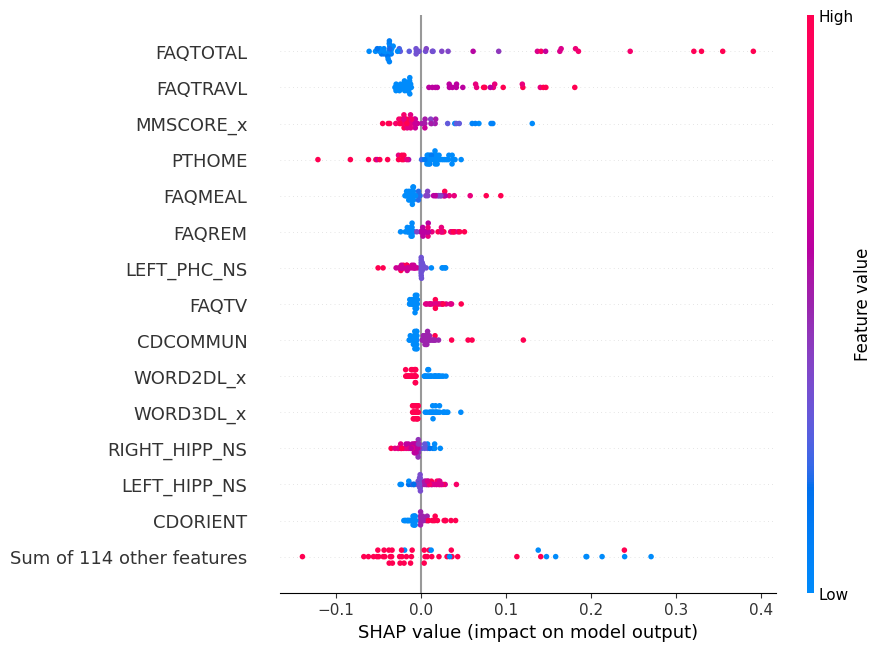

In [ ]:
# shap.plots.beeswarm(
#     shap_values,
#     max_display=15
# )


In [ ]:
# import pandas as pd
# import numpy as np

# mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

# shap_importance = pd.DataFrame({
#     "feature": feature_names,
#     "mean_abs_shap": mean_abs_shap
# })

# shap_importance = shap_importance.sort_values(
#     "mean_abs_shap",
#     ascending=False
# ).reset_index(drop=True)

# # print(shap_importance)


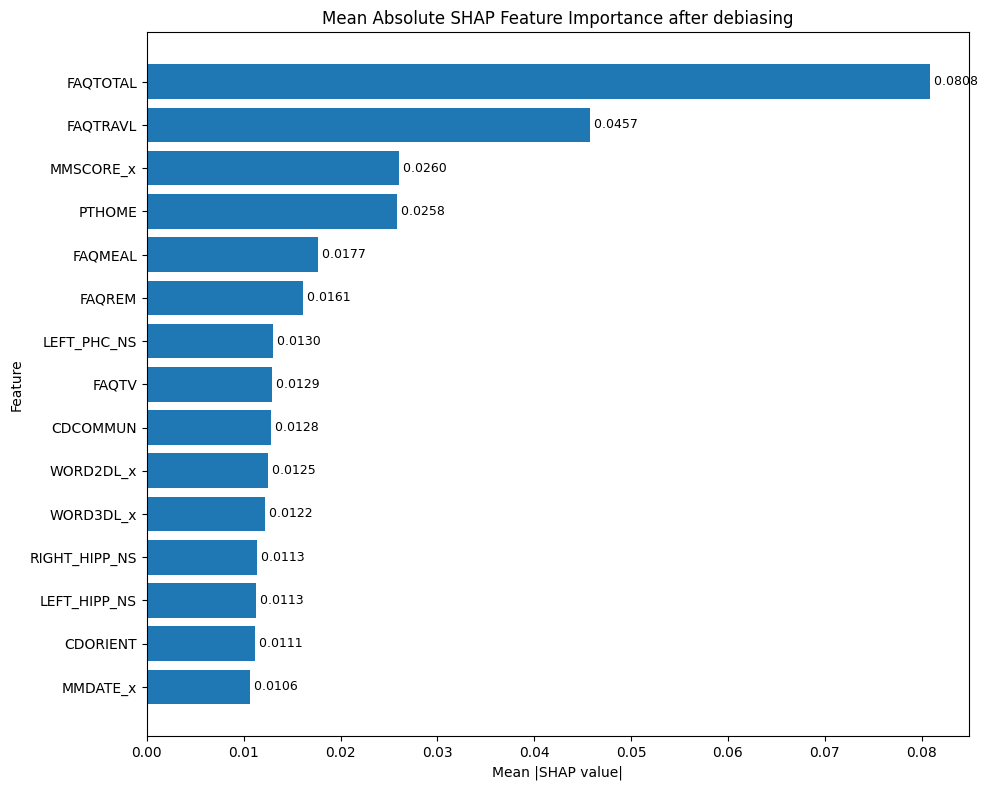

In [ ]:
# import matplotlib.pyplot as plt
# import numpy as np

# # Top 20 features
# top = shap_importance.head(15).sort_values("mean_abs_shap")

# fig, ax = plt.subplots(figsize=(10, 8))

# bars = ax.barh(
#     top["feature"],
#     top["mean_abs_shap"]
# )

# # Add values to the bars
# for bar, value in zip(bars, top["mean_abs_shap"]):
#     ax.text(
#         value,
#         bar.get_y() + bar.get_height() / 2,
#         f" {value:.4f}",
#         va="center",
#         fontsize=9
#     )

# ax.set_xlabel("Mean |SHAP value|")
# ax.set_ylabel("Feature")
# ax.set_title("Mean Absolute SHAP Feature Importance after debiasing")

# plt.tight_layout()
# plt.show()


In [ ]:
# import numpy as np
# import pandas as pd
# from scipy.stats import ttest_1samp, t
# from statsmodels.stats.multitest import multipletests

# # ============================================================
# # SHAP statistical analysis
# # ============================================================

# shap_matrix = shap_values.values

# results = []

# for j, feature in enumerate(feature_names):

#     # SHAP values for this feature
#     values = shap_matrix[:, j]

#     # Remove NaN / infinite values
#     values = values[np.isfinite(values)]

#     n = len(values)

#     # Skip feature if insufficient observations
#     if n < 2:
#         continue

#     # --------------------------------------------------------
#     # One-sample t-test: H0: mean SHAP = 0
#     # --------------------------------------------------------
#     t_stat, p_value = ttest_1samp(
#         values,
#         popmean=0
#     )

#     # --------------------------------------------------------
#     # Mean SHAP
#     # --------------------------------------------------------
#     mean_shap = np.mean(values)

#     # --------------------------------------------------------
#     # Standard error
#     # --------------------------------------------------------
#     se = np.std(
#         values,
#         ddof=1
#     ) / np.sqrt(n)

#     # --------------------------------------------------------
#     # 95% CI using t-distribution
#     # --------------------------------------------------------
#     df = n - 1

#     critical_t = t.ppf(
#         0.975,
#         df
#     )

#     ci_low = mean_shap - critical_t * se
#     ci_high = mean_shap + critical_t * se

#     results.append({
#         "Feature": feature,
#         "Mean SHAP": mean_shap,
#         "CI Lower": ci_low,
#         "CI Upper": ci_high,
#         "T": t_stat,
#         "p": p_value,
#         "N": n
#     })


# # ============================================================
# # Create results DataFrame
# # ============================================================

# results_df = pd.DataFrame(results)


# # ============================================================
# # FDR correction (Benjamini-Hochberg)
# # ============================================================

# valid = (
#     results_df["p"].notna()
#     & np.isfinite(results_df["p"])
# )

# results_df["p_FDR"] = np.nan

# results_df.loc[valid, "p_FDR"] = multipletests(
#     results_df.loc[valid, "p"],
#     method="fdr_bh"
# )[1]


# # ============================================================
# # Keep only FDR-significant features
# # ============================================================

# significant_df = results_df[
#     results_df["p_FDR"] < 0.05
# ].copy()


# # ============================================================
# # Sort by absolute mean SHAP
# # ============================================================

# significant_df = significant_df.reindex(
#     significant_df["Mean SHAP"]
#     .abs()
#     .sort_values(ascending=False)
#     .index
# )


# # ============================================================
# # Create formatted 95% CI
# # ============================================================

# significant_df["95% CI"] = significant_df.apply(
#     lambda row:
#         f"[{row['CI Lower']:.4f}, {row['CI Upper']:.4f}]",
#     axis=1
# )


# # ============================================================
# # Format p-values
# # ============================================================

# def format_p(p):
#     if p < 0.001:
#         return "<0.001"
#     else:
#         return f"{p:.3f}"


# significant_df["p"] = significant_df["p"].apply(format_p)
# significant_df["p_FDR"] = significant_df["p_FDR"].apply(format_p)


# # ============================================================
# # Final publication-style table
# # ============================================================

# final_table = significant_df[
#     [
#         "Feature",
#         "Mean SHAP",
#         "95% CI",
#         "T",
#         "p",
#         "p_FDR"
#     ]
# ].copy()


# # Round numerical columns
# final_table["Mean SHAP"] = final_table["Mean SHAP"].round(6)
# final_table["T"] = final_table["T"].round(2)


# # ============================================================
# # Print table
# # ============================================================

# print("\nStatistically Significant SHAP Features after debiasing")
# print("=" * 90)

# print(
#     final_table.to_string(
#         index=False
#     )
# )

# print("\nNumber of FDR-significant features:",
#       len(final_table))



Statistically Significant SHAP Features after debiasing
        Feature  Mean SHAP             95% CI      T      p  p_FDR
       FAQTRAVL   0.025458   [0.0091, 0.0419]   3.12  0.003  0.023
    LEFT_PHC_NS  -0.007253 [-0.0119, -0.0026]  -3.16  0.003  0.023
  RIGHT_HIPP_NS  -0.007116 [-0.0106, -0.0036]  -4.07 <0.001  0.003
   LEFT_HIPP_NS   0.005966   [0.0021, 0.0098]   3.13  0.003  0.023
   RIGHT_PHC_NS   0.005236   [0.0026, 0.0079]   4.00 <0.001  0.003
   RIGHT_SUB_NS  -0.003984 [-0.0063, -0.0017]  -3.53 <0.001  0.011
    LEFT_SUB_NS   0.003646   [0.0014, 0.0059]   3.30  0.002  0.019
    RIGHT_CA_NS  -0.003312 [-0.0054, -0.0012]  -3.15  0.003  0.023
 LEFT_SULCUS_NS   0.003033   [0.0011, 0.0050]   3.08  0.003  0.025
   RIGHT_CA1_NS  -0.002298 [-0.0035, -0.0011]  -3.75 <0.001  0.006
     LEFT_CA_NS   0.002148   [0.0007, 0.0036]   2.99  0.004  0.029
RIGHT_SULCUS_NS   0.001886   [0.0010, 0.0028]   4.22 <0.001  0.002
   GENOTYPE_2/3   0.001529   [0.0014, 0.0017]  17.77 <0.001 <0.001
     

In [ ]:
# final_table.to_csv(
#     "significant_shap_features_debiased.csv",
#     index=False
# )


SHAP analysis on plain_model


In [79]:
model = plain_model
background = shap.sample(
    X_train_df,
    50,
    random_state=42
)

X_explain = X_valid_df.iloc[:50]

explainer = shap.Explainer(
    predict_fn,
    background
)

shap_values = explainer(X_explain)
print(shap_values.shape)

(50, 128)


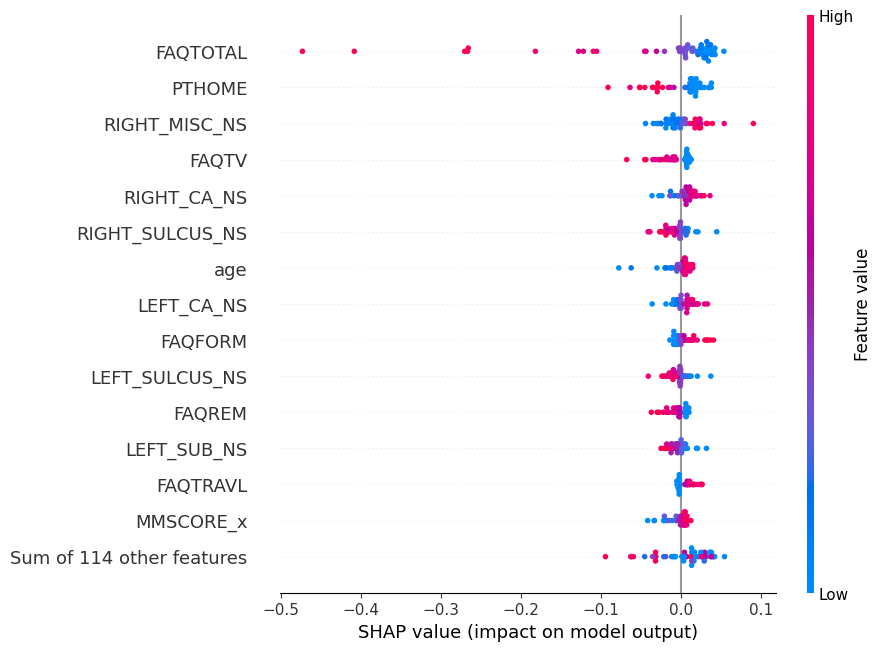

In [80]:
shap.plots.beeswarm(
    shap_values,
    max_display=15
)

In [81]:
import pandas as pd
import numpy as np

mean_abs_shap = np.abs(shap_values.values).mean(axis=0)

shap_importance = pd.DataFrame({
    "feature": feature_names,
    "mean_abs_shap": mean_abs_shap
})

shap_importance = shap_importance.sort_values(
    "mean_abs_shap",
    ascending=False
).reset_index(drop=True)

# print(shap_importance)

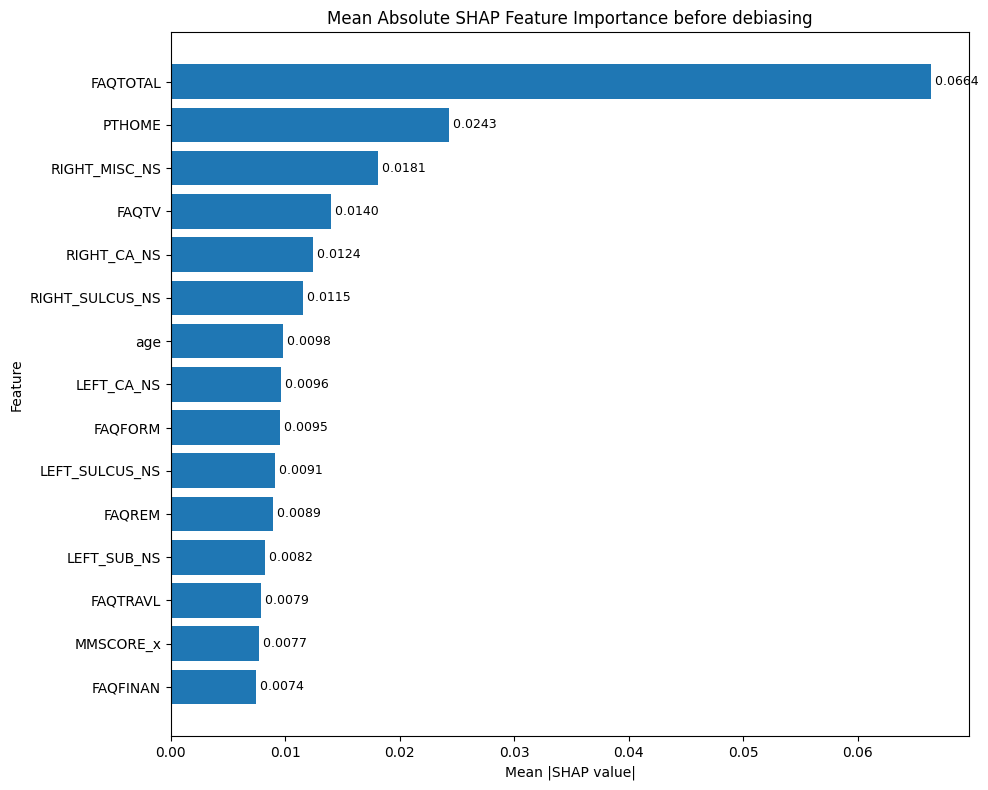

In [82]:
import matplotlib.pyplot as plt
import numpy as np

# Top 20 features
top = shap_importance.head(15).sort_values("mean_abs_shap")

fig, ax = plt.subplots(figsize=(10, 8))

bars = ax.barh(
    top["feature"],
    top["mean_abs_shap"]
)

# Add values to the bars
for bar, value in zip(bars, top["mean_abs_shap"]):
    ax.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.4f}",
        va="center",
        fontsize=9
    )

ax.set_xlabel("Mean |SHAP value|")
ax.set_ylabel("Feature")
ax.set_title("Mean Absolute SHAP Feature Importance before debiasing")

plt.tight_layout()
plt.show()


In [83]:
import numpy as np
import pandas as pd
from scipy.stats import ttest_1samp, t
from statsmodels.stats.multitest import multipletests

# ============================================================
# SHAP statistical analysis
# ============================================================

shap_matrix = shap_values.values

results = []

for j, feature in enumerate(feature_names):

    # SHAP values for this feature
    values = shap_matrix[:, j]

    # Remove NaN / infinite values
    values = values[np.isfinite(values)]

    n = len(values)

    # Skip feature if insufficient observations
    if n < 2:
        continue

    # --------------------------------------------------------
    # One-sample t-test: H0: mean SHAP = 0
    # --------------------------------------------------------
    t_stat, p_value = ttest_1samp(
        values,
        popmean=0
    )

    # --------------------------------------------------------
    # Mean SHAP
    # --------------------------------------------------------
    mean_shap = np.mean(values)

    # --------------------------------------------------------
    # Standard error
    # --------------------------------------------------------
    se = np.std(
        values,
        ddof=1
    ) / np.sqrt(n)

    # --------------------------------------------------------
    # 95% CI using t-distribution
    # --------------------------------------------------------
    df = n - 1

    critical_t = t.ppf(
        0.975,
        df
    )

    ci_low = mean_shap - critical_t * se
    ci_high = mean_shap + critical_t * se

    results.append({
        "Feature": feature,
        "Mean SHAP": mean_shap,
        "CI Lower": ci_low,
        "CI Upper": ci_high,
        "T": t_stat,
        "p": p_value,
        "N": n
    })


# ============================================================
# Create results DataFrame
# ============================================================

results_df = pd.DataFrame(results)


# ============================================================
# FDR correction (Benjamini-Hochberg)
# ============================================================

valid = (
    results_df["p"].notna()
    & np.isfinite(results_df["p"])
)

results_df["p_FDR"] = np.nan

results_df.loc[valid, "p_FDR"] = multipletests(
    results_df.loc[valid, "p"],
    method="fdr_bh"
)[1]


# ============================================================
# Keep only FDR-significant features
# ============================================================

significant_df = results_df[
    results_df["p_FDR"] < 0.05
].copy()


# ============================================================
# Sort by absolute mean SHAP
# ============================================================

significant_df = significant_df.reindex(
    significant_df["Mean SHAP"]
    .abs()
    .sort_values(ascending=False)
    .index
)


# ============================================================
# Create formatted 95% CI
# ============================================================

significant_df["95% CI"] = significant_df.apply(
    lambda row:
        f"[{row['CI Lower']:.4f}, {row['CI Upper']:.4f}]",
    axis=1
)


# ============================================================
# Format p-values
# ============================================================

def format_p(p):
    if p < 0.001:
        return "<0.001"
    else:
        return f"{p:.3f}"


significant_df["p"] = significant_df["p"].apply(format_p)
significant_df["p_FDR"] = significant_df["p_FDR"].apply(format_p)


# ============================================================
# Final publication-style table
# ============================================================

final_table = significant_df[
    [
        "Feature",
        "Mean SHAP",
        "95% CI",
        "T",
        "p",
        "p_FDR"
    ]
].copy()


# Round numerical columns
final_table["Mean SHAP"] = final_table["Mean SHAP"].round(6)
final_table["T"] = final_table["T"].round(2)


# ============================================================
# Print table
# ============================================================

print("\nStatistically Significant SHAP Features before debiasing")
print("=" * 90)

print(
    final_table.to_string(
        index=False
    )
)

print("\nNumber of FDR-significant features:",
      len(final_table))



Statistically Significant SHAP Features before debiasing
        Feature  Mean SHAP             95% CI      T      p  p_FDR
    RIGHT_CA_NS   0.006505   [0.0026, 0.0104]   3.35  0.002  0.015
RIGHT_SULCUS_NS  -0.005981 [-0.0101, -0.0019]  -2.91  0.005  0.039
       FAQTRAVL   0.004807   [0.0021, 0.0075]   3.62 <0.001  0.007
     LEFT_CA_NS   0.004668   [0.0013, 0.0081]   2.77  0.008  0.045
   RIGHT_PHC_NS   0.003054   [0.0014, 0.0047]   3.62 <0.001  0.007
  RIGHT_HIPP_NS   0.002902   [0.0014, 0.0044]   3.79 <0.001  0.006
   RIGHT_SUB_NS   0.002571   [0.0012, 0.0039]   3.91 <0.001  0.005
    LEFT_PHC_NS   0.002061   [0.0008, 0.0033]   3.30  0.002  0.016
   GENOTYPE_3/3  -0.001370 [-0.0023, -0.0004]  -2.81  0.007  0.045
   RIGHT_CA1_NS  -0.001071 [-0.0016, -0.0005]  -3.74 <0.001  0.006
   LEFT_HIPP_NS   0.000944   [0.0006, 0.0013]   4.88 <0.001 <0.001
          MMR_x   0.000621   [0.0002, 0.0010]   3.22  0.002  0.017
      WORD3DL_x  -0.000514 [-0.0009, -0.0001]  -2.79  0.008  0.045
    

In [84]:
final_table.to_csv(
    "significant_shap_features_original.csv",
    index=False
)

### Prejudice Remover (in-processing)


In [70]:
#warnings.filterwarnings("ignore")
## # Learn parameters with debias set to True
#debiased_model_PR = aif360.algorithms.inprocessing.PrejudiceRemover()
#debiased_model_PR.fit(dataset_orig_train)

#dataset_debiasing_PR_train = debiased_model_PR.predict(dataset_orig_train)
#dataset_debiasing_PR_valid = debiased_model_PR.predict(dataset_orig_valid)

In [71]:
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_PR = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_PR):
    
#    fav_inds = dataset_debiasing_PR_valid.scores > class_thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    classified_metric_valid_PR = ClassificationMetric(dataset_orig_valid,
#                                             dataset_debiasing_PR_valid, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
    
#    ba_arr[idx] = 0.5*(classified_metric_valid_PR.true_positive_rate()\
#                       +classified_metric_valid_PR.true_negative_rate())

#best_ind = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_PR = class_thresh_arr_PR[best_ind]
#display(Markdown("#### Predictions of testing data after Prejudice Remover"))

#bal_acc_arr_PR = []
#disp_imp_arr_PR = []
## avg_odds_diff_arr_PR = []
#mean_diff_arr_PR = []

#print("Classification threshold used = %.4f" % best_class_thresh_PR)
#for thresh in tqdm(class_thresh_arr_PR):
    
#    if thresh == best_class_thresh_PR:
#        disp = True
#    else:
#        disp = False
  
#    fav_inds = dataset_debiasing_PR_valid.scores > thresh
#    dataset_debiasing_PR_valid.labels[fav_inds] = dataset_debiasing_PR_valid.favorable_label
#    dataset_debiasing_PR_valid.labels[~fav_inds] = dataset_debiasing_PR_valid.unfavorable_label
    
#    metric_valid_aft = compute_metrics(dataset_orig_valid, dataset_debiasing_PR_valid, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_PR.append(metric_valid_aft["Balanced accuracy"])
#    # avg_odds_diff_arr_PR.append(metric_test_aft["Average odds difference"])
#    disp_imp_arr_PR.append(metric_valid_aft["Disparate impact"])
#    mean_diff_arr_PR.append(metric_valid_aft["Mean Difference"])

### Calibrated Equal Odds Postprocessing 


In [72]:
# # Calibrated Equal Odds Post-processing

# # cost constraint of fnr will optimize generalized false negative rates, that of
# # fpr will optimize generalized false positive rates, and weighted will optimize
# # a weighted combination of both
#cost_constraint = "fnr" # "fnr", "fpr", "weighted"
# #random seed for calibrated equal odds prediction
#randseed = 12345679 

#cm_pred_valid = ClassificationMetric(dataset_orig_valid, dataset_orig_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Original-Predicted validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_pred_valid.difference(cm_pred_valid.generalized_false_negative_rate))

In [73]:
# # # Learn parameters to equalize odds and apply to create a new dataset
#cpp = CalibratedEqOddsPostprocessing(privileged_groups = privileged_groups,
#                                     unprivileged_groups = unprivileged_groups,
#                                     cost_constraint=cost_constraint,
#                                     seed=randseed)
#cpp = cpp.fit(dataset_orig_valid, dataset_orig_valid_pred)
#dataset_transf_valid_pred = cpp.predict(dataset_orig_valid_pred)

In [74]:
#cm_transf_valid = ClassificationMetric(dataset_orig_valid, dataset_transf_valid_pred,
#                             unprivileged_groups=unprivileged_groups,
#                             privileged_groups=privileged_groups)
#display(Markdown("#### Transformed validation dataset"))
#print("Difference in GFPR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_positive_rate))
#print("Difference in GFNR between unprivileged and privileged groups")
#print(cm_transf_valid.difference(cm_transf_valid.generalized_false_negative_rate))

In [75]:
#all_thresh = np.linspace(0.01, 0.99, 25)
#display(Markdown("#### Classification thresholds used for validation and parameter selection"))
#aft_avg_odds_diff_test = []
#bef_bal_acc_valid = []
#aft_bal_acc_valid = []

#for thresh in tqdm(all_thresh):
 
#    dataset_orig_valid_pred_thresh = dataset_orig_valid_pred.copy(deepcopy=True)
#    dataset_cpp_transf_valid_pred_thresh = dataset_transf_valid_pred.copy(deepcopy=True)
    
#    y_temp = np.zeros_like(dataset_orig_valid_pred_thresh.labels)
#    y_temp[dataset_orig_valid_pred_thresh.scores >= thresh] = dataset_orig_valid_pred_thresh.favorable_label
#    y_temp[~(dataset_orig_valid_pred_thresh.scores >= thresh)] = dataset_orig_valid_pred_thresh.unfavorable_label
#    dataset_orig_valid_pred_thresh.labels = y_temp
    

#    classified_metric_orig_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_orig_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
 #                                                privileged_groups=privileged_groups)
    # bef_avg_odds_diff_test.append(classified_metric_orig_test.equal_opportunity_difference())
#    bef_bal_acc_valid.append(0.5*(classified_metric_orig_valid.true_positive_rate()+
#                              classified_metric_orig_valid.true_negative_rate()))

    
#     # Metrics for transf test data
#    classified_metric_transf_valid = ClassificationMetric(dataset_orig_valid,
#                                                 dataset_cpp_transf_valid_pred_thresh,
#                                                 unprivileged_groups=unprivileged_groups,
#                                                 privileged_groups=privileged_groups)
#    # aft_avg_odds_diff_test.append(classified_metric_transf_valid.equal_opportunity_difference())
#    aft_bal_acc_valid.append(0.5*(classified_metric_transf_valid.true_positive_rate()+
#                                   classified_metric_transf_valid.true_negative_rate()))

In [76]:
# # # Predictions from the  cEOP-transformed test set at the optimal classification threshold
#num_thresh = 100
#ba_arr = np.zeros(num_thresh)
#class_thresh_arr_transf_cpp = np.linspace(0.01, 0.99, num_thresh)
#for idx, class_thresh in enumerate(class_thresh_arr_transf_cpp):
    
#    fav_inds = dataset_transf_valid_pred.scores > class_thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
  
#    classified_metric_valid_transf_cpp = ClassificationMetric(dataset_orig_valid,
 #                                            dataset_transf_valid_pred, 
#                                             unprivileged_groups=unprivileged_groups,
#                                             privileged_groups=privileged_groups)
#    
#    ba_arr[idx] = 0.5*(classified_metric_valid_transf_cpp.true_positive_rate()\
#                       +classified_metric_valid_transf_cpp.true_negative_rate())
#best_ind_cpp = np.where(ba_arr == np.max(ba_arr))[0][0]
#best_class_thresh_cpp = class_thresh_arr_transf_cpp[best_ind_cpp]

#display(Markdown("#### Predictions from  cEOP-transformed testing data"))
#bal_acc_arr_transf_cpp = []
#disp_imp_arr_transf_cpp = []
## avg_odds_diff_arr_transf_cpp = []
#mean_diff_arr_transf_cpp = []

#print("Classification threshold used = %.4f" % best_class_thresh_cpp)
#for thresh in tqdm(class_thresh_arr_transf_cpp):
    
#    if thresh == best_class_thresh_cpp:
#        disp = True
#    else:
#        disp = False
   
#    fav_inds = dataset_transf_valid_pred.scores > thresh
#    dataset_transf_valid_pred.labels[fav_inds] = dataset_transf_valid_pred.favorable_label
#    dataset_transf_valid_pred.labels[~fav_inds] = dataset_transf_valid_pred.unfavorable_label
    
#    metric_valid_aft_cpp = compute_metrics(dataset_orig_valid, dataset_transf_valid_pred, 
#                                      unprivileged_groups, privileged_groups,
#                                      disp = disp)

#    bal_acc_arr_transf_cpp.append(metric_valid_aft_cpp["Balanced accuracy"])
    # avg_odds_diff_arr_transf_cpp.append(metric_test_aft_cpp["Average odds difference"])
#    disp_imp_arr_transf_cpp.append(metric_valid_aft_cpp["Disparate impact"])
#    mean_diff_arr_transf_cpp.append(metric_valid_aft_cpp["Mean Difference"])

### XGBoost classifier on original data (alternative to SVC)


In [77]:
# # XGBoost

# # for grid search
# xgb = XGBClassifier()
# # param_grid = {
# #    'n_estimators': [100, 200, 300],
# #    'learning_rate': [0.01, 0.1, 0.2],
# #    'max_depth': [3, 5, 7],
# #    'min_child_weight': [1, 3, 5],
# #    'subsample': [0.6, 0.8, 1.0],
# #    'colsample_bytree': [0.6, 0.8, 1.0]
# # }
# # grid_search = GridSearchCV(estimator=xgb, param_grid=param_grid, cv=3, n_jobs=-1, verbose=2)
# # grid_search.fit(X_train, y_train)
# # params=grid_search.best_params_
# # print(grid_search.best_params_)


# model = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model.fit(X_train, y_train)

### XGBoost on debiased data 


In [78]:
# # # # # transfer XGBoost model
# model_transf = XGBClassifier(colsample_bytree=1.0, learning_rate=0.1, max_depth=3, min_child_weight=1, 
#                           n_estimators=100, subsample=0.6, reg_alpha=0.1, reg_lambda=1.0, random_state=42)
# model_transf.fit(X_train_transf, y_train_transf)

# pos_ind = np.where(model_transf.classes_ == dataset_transf_train.favorable_label)[0][0]
# y_train_transf_pred = model_transf.predict(X_train_transf)